In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dctn, idctn
import time

In [3]:
def TDMA(a, b, c, d):

    n = len(a)
    cp = np.zeros(n)
    dp = np.zeros(n)
    
    x = np.zeros(n)

    cp[1] = c[1] / b[1]
    dp[1] = d[1] / b[1]

    for i in range(2, n - 1):
        cp[i] = c[i] / (b[i] - a[i] * cp[i - 1])
        dp[i] = (d[i] - a[i] * dp[i - 1]) / (b[i] - a[i] * cp[i - 1])

    x[n - 2] = dp[n - 2]

    for i in range(n - 3, 0, -1):
        x[i] = dp[i] - cp[i] * x[i + 1]

    return x

In [4]:
# Vorticity
def compute_vorticity(u, v, dx, dy):
    nx, ny = u.shape
    omega = np.zeros_like(u)

    for i in range(1, nx-1):
        for j in range(1, ny-1):
            dvdx = (v[i+1,j] - v[i-1,j]) / (2*dx)
            dudy = (u[i,j+1] - u[i,j-1]) / (2*dy)
            omega[i,j] = dvdx - dudy
    
    return omega

In [5]:
# Streamfunction Poisson Solver
def solve_poisson_streamfunction(omega, dx, dy, tol=1e-8, max_iter=100000):
    nx, ny = omega.shape
    psi =np.zeros_like(omega)
    beta = dx / dy
    b2 = beta ** 2
    a = 1.0 / (2.0 * (1 + b2))

    for it in range(max_iter):
        error = 0.0
        for i in range(1, nx-1):
            for j in range(1, ny-1):
                old = psi[i,j]
                psi[i,j] = a * ((psi[i+1,j] + psi[i-1,j]) + b2 * (psi[i,j+1] + psi[i,j-1]) + dx ** 2 * -omega[i,j])
                error += (psi[i,j] - old) ** 2
            if np.sqrt(error) < tol:
                break
    
    return psi

In [6]:
# Function for Boundary Condtion
def bc_vel(u, v, u_lid, nx, ny):
    
    u[0, :] = 0                                # left wall
    u[nx-2, :] = 0                             # right wall
    v[0, :] = -v[1, :]                         # left wall: v = 0
    v[nx-1, :] = -v[nx-2, :]                   # right wall: v = 0


    u[:, 0] = -u[:, 1]                         # bottom wall: u = 0
    u[:, ny-1] = 2 * u_lid - u[:, ny-2]        # top lid: u = u_lid
    v[:, 0] = 0                                # bottom wall: v = 0
    v[:, ny-2] = 0                             # top wall: v = 0

    return u, v

In [7]:
# Parameters
x0 = 0; xmax = 1; nx = 130
y0 = 0; ymax = 1; ny = 130
dx = (xmax - x0) / (nx - 2)
dy = (ymax - y0) / (ny - 2)
Re = 100
dt = 0.005
maxtimestep = 1000000
ptol = 10e-6
veltol = 10e-6
u_lid = 1.0

In [8]:
# Fields Initialisation
phi = np.zeros((nx, ny)) # Pseudo-pressure
p = np.zeros_like(phi) # Real pressure

u = np.zeros((nx - 1, ny))
v = np.zeros((nx, ny - 1))
up = np.zeros_like(u) # p for past
vp = np.zeros_like(v)
du = np.zeros_like(u)
dv = np.zeros_like(v)
un = np.zeros_like(u) # n for new
vn = np.zeros_like(v)
uhat = np.zeros_like(u)
vhat = np.zeros_like(v)

In [9]:
betax = dt / 2.0 / Re / (dx ** 2)
betay = dt / 2.0 / Re / (dy ** 2)

# Initial guess of velocity u
u, v = bc_vel(u,v,u_lid, nx, ny)

In [10]:
for timestep in range(maxtimestep):
    rhsu = np.zeros_like(u)
    rhsv = np.zeros_like(v)

    # Convection + Diffusion for u
    for ix in range(1, nx-2):
        for iy in range(1, ny-1):
            ur = 0.5 * (u[ix+1,iy] ** 2 + u[ix,iy] ** 2)
            ul = 0.5 * (u[ix,iy] ** 2 + u[ix-1,iy] ** 2)
            uvu = 0.25 * (u[ix,iy+1] + u[ix,iy]) * (v[ix+1,iy] + v[ix,iy])
            uvd = 0.25 * (u[ix,iy] + u[ix,iy-1]) * (v[ix+1,iy-1] + v[ix,iy-1])

            urp = 0.5 * (up[ix+1,iy] ** 2 + up[ix,iy] ** 2)
            ulp = 0.5 * (up[ix,iy] ** 2 + up[ix-1,iy] ** 2)
            uvup = 0.25 * (up[ix,iy+1] + up[ix,iy]) * (vp[ix+1,iy] + vp[ix,iy])
            uvdp = 0.25 * (up[ix,iy] + up[ix,iy-1]) * (vp[ix+1,iy-1] + vp[ix,iy-1])

            # Convection assembly
            convection = 1.5 * (ur - ul) / dx + 1.5 * (uvu - uvd) / dy \
                           - 0.5 * (urp - ulp) / dx - 0.5 * (uvup - uvdp) / dy

            diffusion = (u[ix+1,iy] - 2 * u[ix,iy] + u[ix-1,iy]) / dx**2 + \
                        (u[ix,iy+1] - 2 * u[ix,iy] + u[ix,iy-1]) / dy**2

            rhsu[ix,iy] = -dt * convection + dt/Re * diffusion
    

    # TDMA
    a = np.ones(nx - 1) * -betax
    b = np.ones(nx - 1) * (1 + 2 * betax)
    c = np.ones(nx - 1) * -betax

    Y = np.zeros_like(u)

    for iy in range(1, ny - 1):
        Y[:,iy] = TDMA(a, b, c, rhsu[:,iy])

    '''y direction TDMA and get du_ix,iy'''
    a = np.ones(ny) * -betay
    b = np.ones(ny) * (1 + 2 * betay)
    b[1] += betay; b[-2] += betay
    c = np.ones(ny) * -betay

    for ix in range(1, nx - 2):
        du[ix,:] = TDMA(a, b, c, Y[ix,:])

    # Convection + Diffusion for v
    for ix in range(1, nx-1):
        for iy in range(1, ny-2):
            vru = 0.25 * (v[ix+1,iy] + v[ix,iy]) * (u[ix,iy+1] + u[ix,iy])
            vlu = 0.25 * (v[ix,iy] + v[ix-1,iy]) * (u[ix-1,iy+1] + u[ix-1,iy])
            vu = 0.5 * (v[ix,iy+1] ** 2 + v[ix,iy] ** 2)
            vd = 0.5 * (v[ix,iy] ** 2 + v[ix,iy-1] ** 2)

            vrup = 0.25 * (vp[ix+1,iy] + vp[ix,iy]) * (up[ix,iy+1] + up[ix,iy])
            vlup = 0.25 * (vp[ix,iy] + vp[ix-1,iy]) * (up[ix-1,iy+1] + up[ix-1,iy])
            vup = 0.5 * (vp[ix,iy+1] ** 2 + vp[ix,iy] ** 2)
            vdp = 0.5 * (vp[ix,iy] ** 2 + vp[ix,iy-1] ** 2)

            # Convection assembly
            convection = 1.5 * (vru - vlu) / dx + 1.5 * (vu - vd) / dy \
                        - 0.5 * (vrup - vlup) / dx - 0.5 * (vup - vdp) / dy

            diffusion = (v[ix+1,iy] - 2 * v[ix,iy] + v[ix-1,iy]) / dx**2 + \
                        (v[ix,iy+1] - 2 * v[ix,iy] + v[ix,iy-1]) / dy**2

            rhsv[ix,iy] = -dt * convection + dt/Re * diffusion


    # TDMA
    a = np.ones(ny - 1) * -betay
    b = np.ones(ny - 1) * (1 + 2 * betay)
    c = np.ones(ny - 1) * -betay


    X = np.zeros_like(v)

    for ix in range(1, nx - 1):
        X[ix,:] = TDMA(a, b, c, rhsv[ix,:])

    '''x direction TDMA and get dv_ix,iy'''

    a = np.ones(nx) * -betax
    b = np.ones(nx) * (1 + 2 * betax)
    b[1] += betax; b[-2] += betax
    c = np.ones(nx) * -betax

    for iy in range(1, ny - 2):
        dv[:,iy] = TDMA(a, b, c, X[:,iy])



    # Obtaining Intermediate velocity u & v
    uhat = u + du
    vhat = v + dv
    uhat, vhat = bc_vel(uhat, vhat, u_lid, nx, ny)
    

    # Poisson RHS
    f = np.zeros_like(phi)
    for ix in range(1, nx-1):
        for iy in range(1, ny-1):
            f[ix,iy] = ((uhat[ix,iy] - uhat[ix-1,iy]) / dx +\
                        (vhat[ix,iy] - vhat[ix,iy-1]) / dy) / dt

    # For DCT
    
    F = f[1:-1, 1:-1]               # extraction f of inner cells
    F -= F.mean()                   # For mean-zero RHS (Neumann problem with DCT)

    F_hat = dctn(F, type=2, norm='ortho')       # Conducting DCT

    Nx, Ny = F.shape
    kx = np.arange(Nx).reshape(-1,1)
    ky = np.arange(Ny).reshape(1,-1)

    lam = (2 * np.cos(np.pi * kx / (Nx - 1)) - 2) / dx**2 +\
          (2 * np.cos(np.pi * ky / (Ny - 1)) - 2) / dy**2
    lam[0,0] = 1.0                  # prevention of dividing by zero

    phi_hat = F_hat / lam
    phi_hat[0,0] = 0.0              # mean pseudo pressure value is a random value, fixed to zero

    phi_inner = idctn(phi_hat, type=2, norm='ortho')

    phi[1:-1,1:-1] = phi_inner

    # Phi BC
    phi[0, :]     = phi[1, :]       # left
    phi[nx-1, :]  = phi[nx-2, :]    # right
    phi[:, 0]     = phi[:, 1]       # bottom
    phi[:, ny-1]  = phi[:, ny-2]    # top




    # Velocity correction (projection)
    for ix in range(1, nx-2):
        for iy in range(1 , ny-1):
            un[ix,iy] = uhat[ix,iy] - dt * (phi[ix+1,iy] - phi[ix,iy]) / dx

    for ix in range(1, nx-1):
        for iy in range(1, ny-2):
            vn[ix,iy] = vhat[ix,iy] - dt * (phi[ix,iy+1] - phi[ix,iy]) / dy
    

    # Update
    up = u.copy(); vp = v.copy()
    u = un.copy(); v = vn.copy()

    # Applying BC after correction
    u, v = bc_vel(u, v, u_lid, nx, ny)
    up, vp = bc_vel(up, vp, u_lid, nx, ny)
    

    # Obtaining True Pressure
    for iy in range(1, ny - 1):
        p[:,iy] = phi[:,iy] - dt * 0.5 / Re * (phi[:,iy-1] - 2 * phi[:,iy] + phi[:,iy+1]) / (dy ** 2)
    for ix in range(1, nx - 1):
        p[ix,:] += - dt * 0.5 / Re * (phi[ix-1,:] - 2 * phi[ix,:] + phi[ix+1,:]) / (dx ** 2)


    umax = np.max(np.abs(u[:,ny-2]))
    vmax = np.max(np.abs(v))
    print(f"[Step {timestep:5d}] max|u| = {umax:.4f}, max|v| = {vmax:.4f}")

    # Error check before update
    error_u = np.linalg.norm(u - up, ord='fro')
    error_v = np.linalg.norm(v - vp, ord='fro')
    total_error = np.sqrt(error_u**2 + error_v**2)
    print(f"[step {timestep}] error = {total_error:.6e}")

    if timestep > 5 and total_error < veltol:
        print("Converged.")
        break

[Step     0] max|u| = 0.7531, max|v| = 0.2889
[step 0] error = 1.187357e+01
[Step     1] max|u| = 0.7546, max|v| = 0.2786
[step 1] error = 2.729952e+00
[Step     2] max|u| = 0.8104, max|v| = 0.2880
[step 2] error = 1.793614e+00
[Step     3] max|u| = 0.8318, max|v| = 0.3103
[step 3] error = 1.305337e+00
[Step     4] max|u| = 0.8493, max|v| = 0.3245
[step 4] error = 1.068708e+00
[Step     5] max|u| = 0.8617, max|v| = 0.3343
[step 5] error = 9.068985e-01
[Step     6] max|u| = 0.8714, max|v| = 0.3414
[step 6] error = 7.925670e-01
[Step     7] max|u| = 0.8793, max|v| = 0.3468
[step 7] error = 7.060684e-01
[Step     8] max|u| = 0.8857, max|v| = 0.3510
[step 8] error = 6.382582e-01
[Step     9] max|u| = 0.8912, max|v| = 0.3543
[step 9] error = 5.834585e-01
[Step    10] max|u| = 0.8959, max|v| = 0.3570
[step 10] error = 5.381506e-01
[Step    11] max|u| = 0.9000, max|v| = 0.3593
[step 11] error = 4.999884e-01
[Step    12] max|u| = 0.9036, max|v| = 0.3635
[step 12] error = 4.673529e-01
[Step    

In [11]:
x = np.linspace(x0, xmax, nx - 1)
y = np.linspace(y0, ymax, ny - 1)

# Collocated Grid
ucol = np.zeros((nx - 1, ny - 1))
vcol = np.zeros((nx - 1, ny - 1))
pcol = np.zeros((nx - 1, ny - 1))

# Transfering staggered grid data into collocated grid
for j in range(ny - 1):
    ucol[:,j] = (u[:,j] + u[:,j + 1]) / 2
for i in range(nx - 1):
    vcol[i,:] = (v[i,:] + v[i + 1,:]) / 2

# Special treatment for pressure is needed...
pcol[0,:] = 0; pcol[:,0] = 0
pcol[nx - 2,:] = 0; pcol[:,ny - 2] = 0
for i in range(1, nx - 2):
    for j in range(1, ny - 2):
        pcol[i,j] = 0.25 * (p[i,j] + p[i+1,j] + p[i,j+1] + p[i+1,j+1])

In [12]:
u_exp_data = np.array([
    [0.0000,   0.00000,   0.00000,   0.00000],
    [0.0547,  -0.03717,  -0.08186,  -0.18109],
    [0.0625,  -0.04192,  -0.09266,  -0.20196],
    [0.0703,  -0.04775,  -0.10338,  -0.22222],
    [0.1016,  -0.06434,  -0.14612,  -0.29730],
    [0.1719,  -0.10150,  -0.24299,  -0.38289],
    [0.2813,  -0.15662,  -0.32726,  -0.27805],
    [0.4531,  -0.21090,  -0.17119,  -0.10648],
    [0.5000,  -0.20581,  -0.11477,  -0.06080],
    [0.6172,  -0.13641,   0.02135,   0.05702],
    [0.7344,   0.00332,   0.16256,   0.18719],
    [0.8516,   0.23151,   0.29093,   0.33304],
    [0.9531,   0.68717,   0.55892,   0.46604],
    [0.9609,   0.73722,   0.61756,   0.51117],
    [0.9688,   0.78871,   0.68439,   0.57492],
    [0.9766,   0.84123,   0.75837,   0.65928],
    [1.0000,   1.00000,   1.00000,   1.00000]
])

x_exp_re100 = u_exp_data[:,0]
u_exp_re100 = u_exp_data[:,1]

v_exp_data = np.array([
    [0.0000,  0.00000,   0.00000,   0.00000],
    [0.0625,  0.09233,   0.18360,   0.27485],
    [0.0703,  0.10091,   0.19713,   0.29012],
    [0.0781,  0.10890,   0.20920,   0.30353],
    [0.0938,  0.12317,   0.22965,   0.32627],
    [0.1563,  0.16077,   0.28124,   0.37095],
    [0.2266,  0.17507,   0.30203,   0.33075],
    [0.2344,  0.17527,   0.30174,   0.32235],
    [0.5000,  0.05454,   0.05186,   0.02526],
    [0.8047, -0.24533,  -0.38598,  -0.31966],
    [0.8594, -0.22445,  -0.44993,  -0.42665],
    [0.9063, -0.16914,  -0.23827,  -0.51550],
    [0.9453, -0.10313,  -0.22847,  -0.39188],
    [0.9531, -0.08864,  -0.19254,  -0.33714],
    [0.9609, -0.07391,  -0.15663,  -0.27669],
    [0.9688, -0.05906,  -0.12146,  -0.21388],
    [1.0000,  0.00000,   0.00000,   0.00000]
])

y_exp_re100 = v_exp_data[:,0]
v_exp_re100 = v_exp_data[:,1]

In [13]:
# u-velocity along the vertical centreline, v-velocity along the horizontal centreline
center_vert = int((nx - 2) / 2)
center_hori = int((ny - 2) / 2)

u_vertical = ucol[center_vert,:]
v_horizontal = vcol[:,center_hori]

data_uv = np.column_stack((y, u_vertical))
data_uv = data_uv[::-1, :]
np.savetxt("u_vertical_Re100.plt", data_uv, fmt="%.8e")
data_vh = np.column_stack((x, v_horizontal))
np.savetxt("v_horizontal_Re100.plt", data_vh, fmt="%.8e")

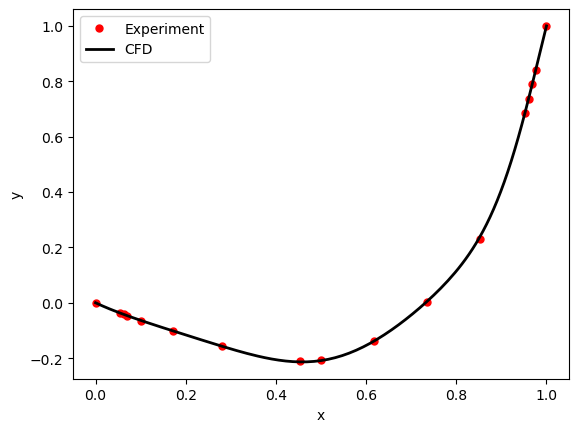

In [14]:
plt.figure()
plt.plot(x_exp_re100, u_exp_re100, linestyle='none', color='r', marker='o', label = 'Experiment', markersize=5)
plt.plot(data_uv[:,0], data_uv[:,1], color='k', label = 'CFD', linewidth='2')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

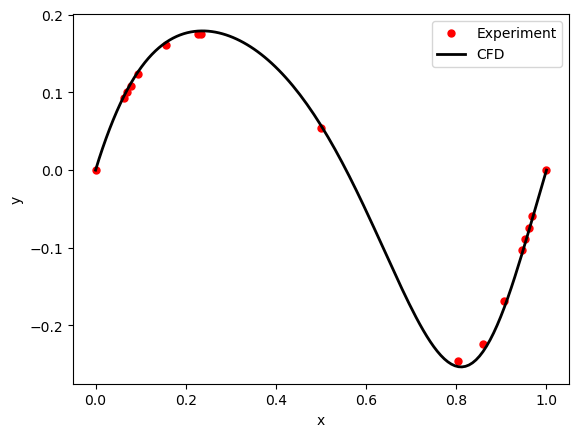

In [15]:
plt.figure()
plt.plot(y_exp_re100, v_exp_re100, linestyle='none', color='r', marker='o', label = 'Experiment', markersize=5)
plt.plot(data_vh[:,0], data_vh[:,1], color='k', label = 'CFD', linewidth='2')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [16]:
# Calculating Vorticity
vortex = compute_vorticity(ucol, vcol, dx, dy)

# Calculating Streamfunction
psi = solve_poisson_streamfunction(vortex, dx, dy)

In [17]:
psi_min, psi_max = psi.min(), psi.max()
print(f"psi_min = {psi_min:.2e}, psi_max = {psi_max:.2e}")

psi_min = -1.68e-05, psi_max = 1.03e-01


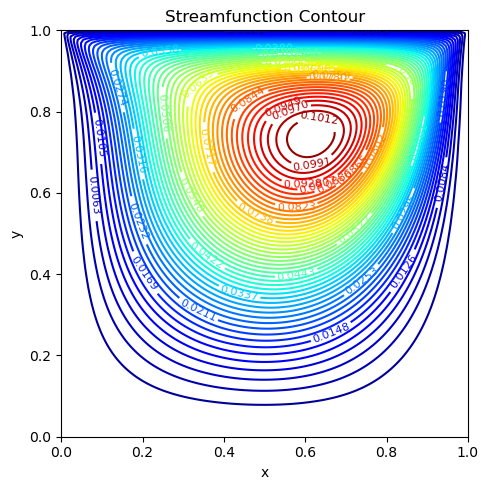

In [18]:
# Streamfunction Plot
X, Y = np.meshgrid(x, y, indexing='ij')
plt.figure(figsize=(6,5))

levels = np.linspace(np.min(psi), np.max(psi), 50)
contour = plt.contour(X, Y, psi, levels=levels, cmap='jet')
plt.clabel(contour, inline=1, fontsize=8)
plt.title("Streamfunction Contour")
plt.xlabel("x")
plt.ylabel("y")
plt.gca().set_aspect('equal')
#plt.colorbar(contour, label="ψ")
plt.tight_layout()
plt.show()

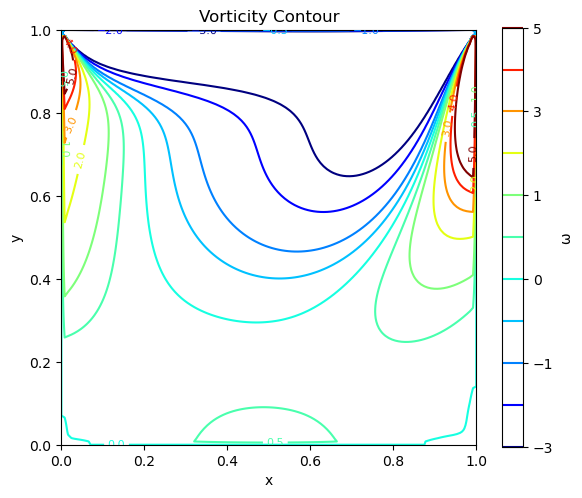

In [19]:
# Vorticity Plot
X, Y = np.meshgrid(x, y)
plt.figure(figsize=(6,5))

levels = [-3, -2, -1, -0.5, 0, 0.5, 1, 2, 3, 4, 5]
contour = plt.contour(X, Y, vortex.T, levels=levels, cmap='jet')
plt.clabel(contour, inline=1, fontsize=8)
plt.title("Vorticity Contour")
plt.xlabel("x")
plt.ylabel("y")
plt.gca().set_aspect('equal')
plt.colorbar(contour, label="ω")
plt.tight_layout()
plt.show()